# Single cells of BR00121438

The single cells behind 24 wells of one JUMP-Target-2 plate {cite:p}`Chandrasekaran_2023`, as CellProfiler measured
them, at four fields of view each.
The same plate's well profiles are in [JUMP-Target-2](jump_target2.ipynb), and its images in
{func}`~mantispy.ds.jump_plate`.

In [1]:
import matplotlib.pyplot as plt

import mantispy as mt

cells = mt.ds.jump_cells()
cells

AnnData object with n_obs × n_vars = 13578 × 5857
    obs: 'Metadata_ImageNumber', 'Metadata_ObjectNumber', 'Metadata_AbsPositionZ', 'Metadata_AbsTime', 'Metadata_BinningX', 'Metadata_BinningY', 'Metadata_ChannelID', 'Metadata_ChannelName', 'Metadata_Col', 'Metadata_ExposureTime', 'Metadata_FieldID', 'Metadata_ImageResolutionX', 'Metadata_ImageResolutionY', 'Metadata_ImageSizeX', 'Metadata_ImageSizeY', 'Metadata_MainEmissionWavelength', 'Metadata_MainExcitationWavelength', 'Metadata_MaxIntensity', 'Metadata_ObjectiveMagnification', 'Metadata_ObjectiveNA', 'Metadata_PlaneID', 'Metadata_Plate', 'Metadata_PositionX', 'Metadata_PositionY', 'Metadata_PositionZ', 'Metadata_Row', 'Metadata_Site', 'Metadata_Well', 'Metadata_Source', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature', 'selected'
    uns: 'mantispy'
    layers: None (.X

## Source

One `ExportToSpreadsheet` directory per field of view, under
`cpg0016-jump/source_4/workspace/analysis/2021_04_26_Batch1/BR00121438/analysis/<plate>-<well>-<site>`, each with
`Image.csv` and the `Cells`, `Cytoplasm` and `Nuclei` tables, about 1.5 GB in all.
The JUMP annotation tables supply the perturbations, as for JUMP-Target-2.

## Choices the loader makes

**Which wells.**
Eight DMSO wells, four compounds at both of their replicate wells, and eight more compounds at one well each.
The compounds that move furthest from DMSO on this plate are cytotoxic, so ranking wells by distance selects empty
wells; every well here holds more than 120 cells in its first field.

In [2]:
wells = mt.tl.aggregate(cells, min_cells=0)
columns = ["Metadata_Well", "Metadata_Perturbation", "Metadata_Control", "Metadata_SiteCount", "Metadata_CellCount"]
wells.obs[columns].sort_values(["Metadata_Control", "Metadata_Perturbation"], ascending=[False, True])

,Metadata_Well,Metadata_Perturbation,Metadata_Control,Metadata_SiteCount,Metadata_CellCount
5,B12,JCP2022_033924,True,4,734
7,D18,JCP2022_033924,True,4,634
8,E05,JCP2022_033924,True,4,697
9,E08,JCP2022_033924,True,4,729
10,F05,JCP2022_033924,True,4,643
14,J04,JCP2022_033924,True,4,749
17,K14,JCP2022_033924,True,4,690
23,O11,JCP2022_033924,True,4,545
19,L19,JCP2022_001036,False,4,555
20,L20,JCP2022_001036,False,4,425


**One row per cell.**
The JUMP pipeline gives `Cytoplasm` a parent in both `Cells` and `Nuclei` and gives `Cells` none, so `Cytoplasm` is
the only object that joins all three tables, and one cytoplasm is one cell.
In every field, `Count_Cells` in `Image.csv` equals the number of `Cytoplasm` rows.

**Which features.**
`var["selected"]` marks the features {func}`~mantispy.pp.feature_select` keeps after
{func}`~mantispy.pp.normalize` against the DMSO wells, with the features it flags as degenerate dropped first.
No step of it draws a random number, so the pinned files always give the same mask.
`mt.ds.jump_cells(selected=True)` returns only those features.

In [3]:
print(f"{int(cells.var['selected'].sum())} of {cells.n_vars} features selected")

1607 of 5857 features selected


## Four of nine fields

The plate was imaged at nine fields per well and four are pinned here, so a well aggregated from these cells counts
the cells of four fields.
{func}`~mantispy.tl.aggregate` records that in `Metadata_SiteCount`, and against the well's count over all nine
fields in JUMP-Target-2 the ratio sits near 4/9:

In [4]:
published = mt.ds.jump_target2(plates=["BR00121438"], annotate=False).obs.set_index("Metadata_Well")
wells.obs["all nine fields"] = published.loc[wells.obs["Metadata_Well"].astype(str), "Metadata_CellCount"].to_numpy()
wells.obs[["Metadata_Well", "Metadata_SiteCount", "Metadata_CellCount", "all nine fields"]].head()

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/2OnMUz3_/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Metadata_Well,Metadata_SiteCount,Metadata_CellCount,all nine fields
0,A02,4,702,1527.0
1,A21,4,582,1234.0
2,B01,4,401,815.0
3,B04,4,555,1243.0
4,B09,4,498,1110.0


ratio: median 0.45, range 0.35 to 0.51


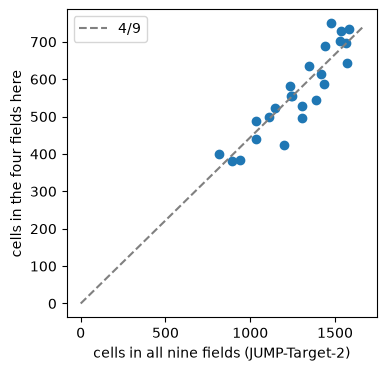

In [5]:
ratio = wells.obs["Metadata_CellCount"] / wells.obs["all nine fields"]
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(wells.obs["all nine fields"], wells.obs["Metadata_CellCount"])
limit = wells.obs["all nine fields"].max() * 1.05
ax.plot([0, limit], [0, limit * 4 / 9], color="grey", linestyle="--", label="4/9")
ax.set_xlabel("cells in all nine fields (JUMP-Target-2)")
ax.set_ylabel("cells in the four fields here")
ax.legend()
print(f"ratio: median {ratio.median():.2f}, range {ratio.min():.2f} to {ratio.max():.2f}")

Divide by `Metadata_SiteCount` before comparing a count from here with one from another dataset;
{func}`~mantispy.tl.cytotoxicity` does so itself.